In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from wasserstein import wasserstein_distance_nd

In [2]:
class FPU:
    """
    FPU data processor. 
    
    Arguments p and q should be (n x 6) 2d arrays representing momentum and position variables of n data points.
    """

    def __init__(self, omega=300):
        self.omega = omega

    def compute_H(self, p, q):
        """Compute total energy / Hamiltonian."""
        return self.compute_U(q) + self.compute_K(p)
    
    def compute_U(self, q):
        """Compute potential energy."""
        dq_stiff = q[:, 1::2] - q[:, ::2]
        dq_soft = np.stack((q[:, 0], q[:, 2]-q[:, 1], q[:, 4]-q[:, 3], -q[:, 5]), axis=-1)
        return 0.25 * self.omega**2 * np.sum(dq_stiff**2, axis=-1) + np.sum(dq_soft**4, axis=-1)
    
    def compute_K(self, p):
        """Compute kinetic energy."""
        return 0.5 * np.sum(p**2, axis=-1)

    def compute_I(self, p, q):
        """Compute energy of stiff springs."""
        x1 = (q[:, 1::2] - q[:, ::2]) / np.sqrt(2.)
        y1 = (p[:, 1::2] - p[:, ::2]) / np.sqrt(2.)
        I = 0.5 * y1**2 + 0.5 * self.omega**2 * x1**2
        I_total = np.sum(I, axis=-1)
        return np.concatenate((I, I_total[:, None]), axis=-1)

    def compute_T0(self, p):
        """Compute total kinetic energy of the mass center motion of stiff springs."""
        y0 = (p[:, 1::2] + p[:, ::2]) / np.sqrt(2.)
        return 0.5 * np.sum(y0**2, axis=-1)
    
    def compute_T1(self, p):
        """Compute total kinetic energy of the relative motion of masses joined by stiff springs."""
        y1 = (p[:, 1::2] - p[:, ::2]) / np.sqrt(2.)
        return 0.5 * np.sum(y1**2, axis=-1)
    


In [3]:
def compute_H(u, omega=300):
    p, q = np.split(u, 2, axis=-1)
    processor = FPU(omega)
    return processor.compute_H(p, q)

def compute_energies(u, omega=300):
    p, q = np.split(u, 2, axis=-1)
    processor = FPU(omega)
    I = processor.compute_I(p, q)
    return {
        "H": processor.compute_H(p, q), 
        "K": processor.compute_K(p),
        "U": processor.compute_U(q),
        "T0": processor.compute_T0(p),
        "T1": processor.compute_T1(p),
        "I1": I[:, 0],
        "I2": I[:, 1],
        "I3": I[:, 2],
        "I_tot": I[:, 3]}


In [4]:

# def load_data(data_dir, traj_len):
#     """Load FPU data from data directory."""

#     filenames = [f"U{n}.csv" for n in range(traj_len+1)]
#     data = []
#     for fname in filenames: 
#         u = pd.read_csv(os.path.join(data_dir, fname)).to_numpy()
#         data.append(u)
#     data = np.stack(data)

#     print("data shape: (trajectory length, number of trajectories, state space dimension)")
#     print("\t", data.shape)
    
#     return data


# def plot_trajectory(traj, Dt):
#     """Plot trajectory in the projected phase space: (q1, q3, q5)"""

#     fig = plt.figure(figsize=(5, 5), dpi=200)
#     ax = fig.add_subplot(projection="3d")
#     ax.plot(traj[:, 6], traj[:, 8], traj[:, 10], ".-", label="trajectory")
#     ax.plot(traj[0, 6], traj[0, 8], traj[0, 10], "*", label="initial state")
#     ax.set_xlabel("$q_1$")
#     ax.set_ylabel("$q_3$")
#     ax.set_zlabel("$q_5$")
#     ax.set_title("Trajectory in phase space $T=[0, {:.3g}]$".format((len(traj)-1)*Dt))
#     ax.legend(loc="best")
#     plt.show()


# def plot_stiff_spring_energies(traj, Dt, omega=300.):
#     """Plot energy of stiff springs vs time."""

#     n = len(traj)-1
#     tt = np.linspace(0, n*Dt, n+1)

#     fpu = FPU(omega=omega)
#     H = fpu.compute_H(traj[:, :6], traj[:, 6:])
#     I = fpu.compute_I(traj[:, :6], traj[:, 6:])

#     plt.figure(figsize=(5, 4), dpi=200)
#     plt.plot(tt, H, "k", label="$H$")
#     plt.plot(tt, I[:, 3], label="$I_{total}$")
#     plt.plot(tt, I[:, 0], label="$I_1$")
#     plt.plot(tt, I[:, 1], label="$I_2$")
#     plt.plot(tt, I[:, 2], label="$I_3$")
#     plt.xlim(tt.min(), tt.max())
#     plt.xlabel("t")
#     plt.title("Energy of stiff springs")
#     plt.legend(loc="best")
#     plt.show()
#     plt.close()
    

# def plot_kinetic_energies(traj, Dt, omega=300.):
#     """Plot kinetic energy components vs time."""
#     n = len(traj)-1
#     tt = np.linspace(0, n*Dt, n+1)

#     fpu = FPU(omega=omega)
#     H = fpu.compute_H(traj[:, :6], traj[:, 6:])
#     T0 = fpu.compute_T0(traj[:, :6])
#     T1 = fpu.compute_T1(traj[:, :6])

#     plt.figure(figsize=(5, 4), dpi=200)
#     plt.plot(tt, H, "k", label="$H$")
#     plt.plot(tt, T0, label="$T_0$")
#     plt.plot(tt, T1, label="$T_1$")
#     plt.plot(tt, T0+T1, label="$T_0+T_1$")
#     plt.xlim(tt.min(), tt.max())
#     plt.xlabel("t")
#     plt.title("Kinetic energy")
#     plt.legend(loc="best")
#     plt.show()
#     plt.close()

In [5]:
def load_data(filepath, dt=0.05):

    df = pd.read_csv(filepath)
    u = df.values
    t = np.arange(0, len(u)*dt, dt)
    print(u.shape)
    
    return u, t

## Dataset descriptions


Directory: /workspace/projects_rui/learnsolnmap/data1/fpu/omega=300/

| Subdirectory | Method          | Number of points | Parameters | Comment | 
| :---------   | :------:        | :--------------: | :-------:  | :-----: |
| version1   |   HMC-H0 (old)        |     200k          | $\sigma=0.1, \delta t=0.5, N=2000, N_\text{chains}=100, x_\text{init}=\mathcal{x}, v_\text{init}=\mathcal{v}, H_0=H(v_\text{init}, x_\text{init})=2.00003$   |  | 
| version2    |   TrajEnsemble (old)       |     200k          | $\sigma=0.1, \delta t=0.125, N=50, N_\text{chains}=4000, x_\text{init}=\mathcal{x}, v_\text{init}=\mathcal{v}, H_0=H(v_\text{init}, x_\text{init})=2.00003$   |  | 
| version3    |   HMC-H0        |   200k   | $\epsilon=0.2, \delta t=0.5, N=500, N_\text{chains}=400, x_\text{init}=\mathcal{x}, v_\text{init}=\mathcal{v}, H_0=H(v_\text{init}, x_\text{init})=2.00003$   |  | 
| version4    |   RHMC-H0        |   200k   | $\epsilon=0.2, \delta t=0.5, N=500, N_\text{chains}=400, x_\text{init}=\mathcal{x}, v_\text{init}=\mathcal{v}, H_0=H(v_\text{init}, x_\text{init})=2.00003$   |  | 

In [5]:
filepath_list = [
    "/workspace/projects_rui/learnsolnmap/data1/fpu/omega=300/version1/inputs/U0.csv",  # HMC-H0 (old) sigma=0.1
    "/workspace/projects_rui/learnsolnmap/data1/fpu/omega=300/version3/inputs/U0.csv",  # HMC-H0 epsilon=0.2
    "/workspace/projects_rui/learnsolnmap/data1/fpu/omega=300/version4/inputs/U0.csv",  # RHMC-H0 epsilon=0.2
]

label_list = [
    "HMC-H0 old",
    "HMC-H0",
    "RHMC-H0",
    ]

datasets = [load_data(filepath)[0] for filepath in filepath_list]

(200000, 12)
(200000, 12)
(200000, 12)


In [6]:
filepath_list = [
    "/workspace/projects_rui/learnsolnmap/data1/fpu/omega=50/version1/inputs/U0.csv",  # RHMC-H0 epsilon=0.2
]

label_list = [
    "RHMC-H0",
    ]

datasets = [load_data(filepath)[0] for filepath in filepath_list]

(200000, 12)


RHMC-H0:	 mean(H) = 1.987905242258298	 std(H) = 0.21760893927119923


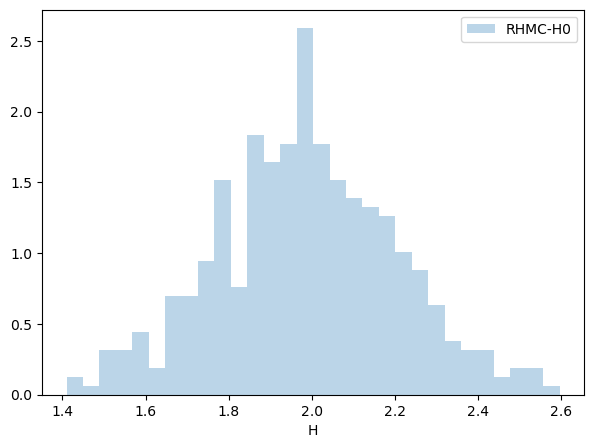

In [7]:
# Plot total energy histogram

for u, label in zip(datasets, label_list):
    H = compute_H(u, omega=50)
    print(f"{label}:\t mean(H) = {H.mean()}\t std(H) = {H.std()}")

plt.figure(figsize=(7, 5))
for u, label in zip(datasets, label_list):
    H = compute_H(u, omega=50)
    plt.hist(H[:], bins=30, density=True, alpha=0.3, label=label)
plt.xlabel("H")
plt.legend()
plt.show()

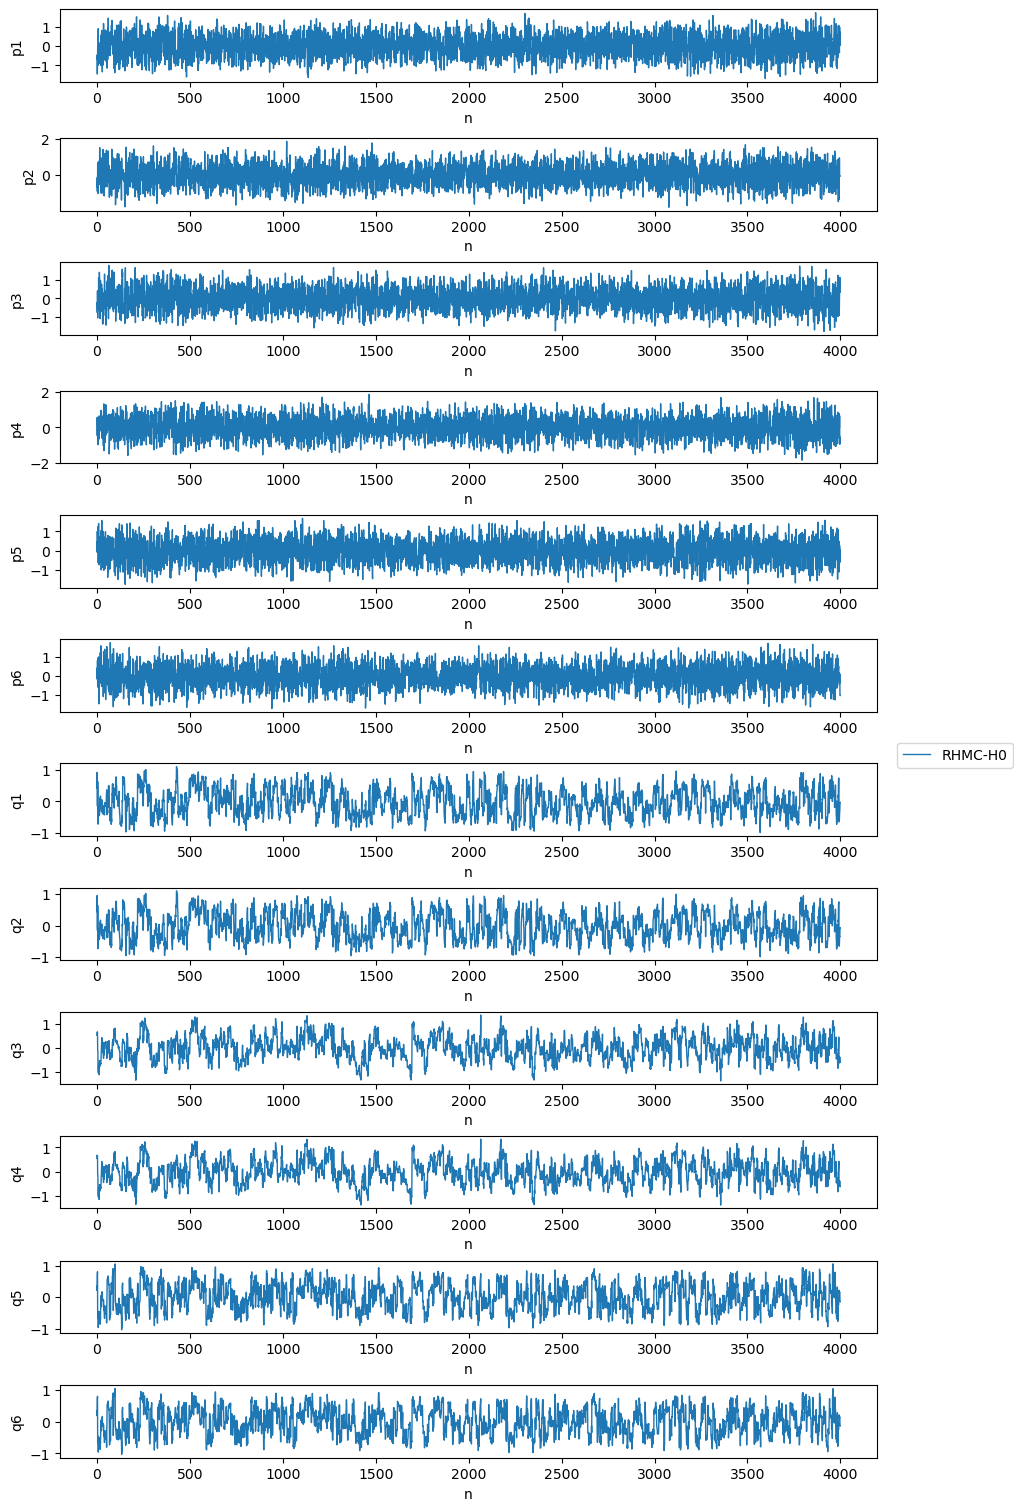

In [8]:
# Trace plot

indices = np.arange(len(datasets[0]))[:4000:1]

fig, axes = plt.subplots(12, 1, figsize=(10, 15), layout='constrained')

for i, ax in enumerate(axes):
    for u, label in zip(datasets, label_list):
        ax.plot(indices, u[indices, i], "-", lw=1, label=label)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    ax.set_xlabel("n")
    if i < 6:
        ax.set_ylabel(f"p{i+1}")
    else:
        ax.set_ylabel(f"q{i-5}")

fig.legend(handles, labels, loc='outside center right', borderaxespad=0.1)
plt.show()

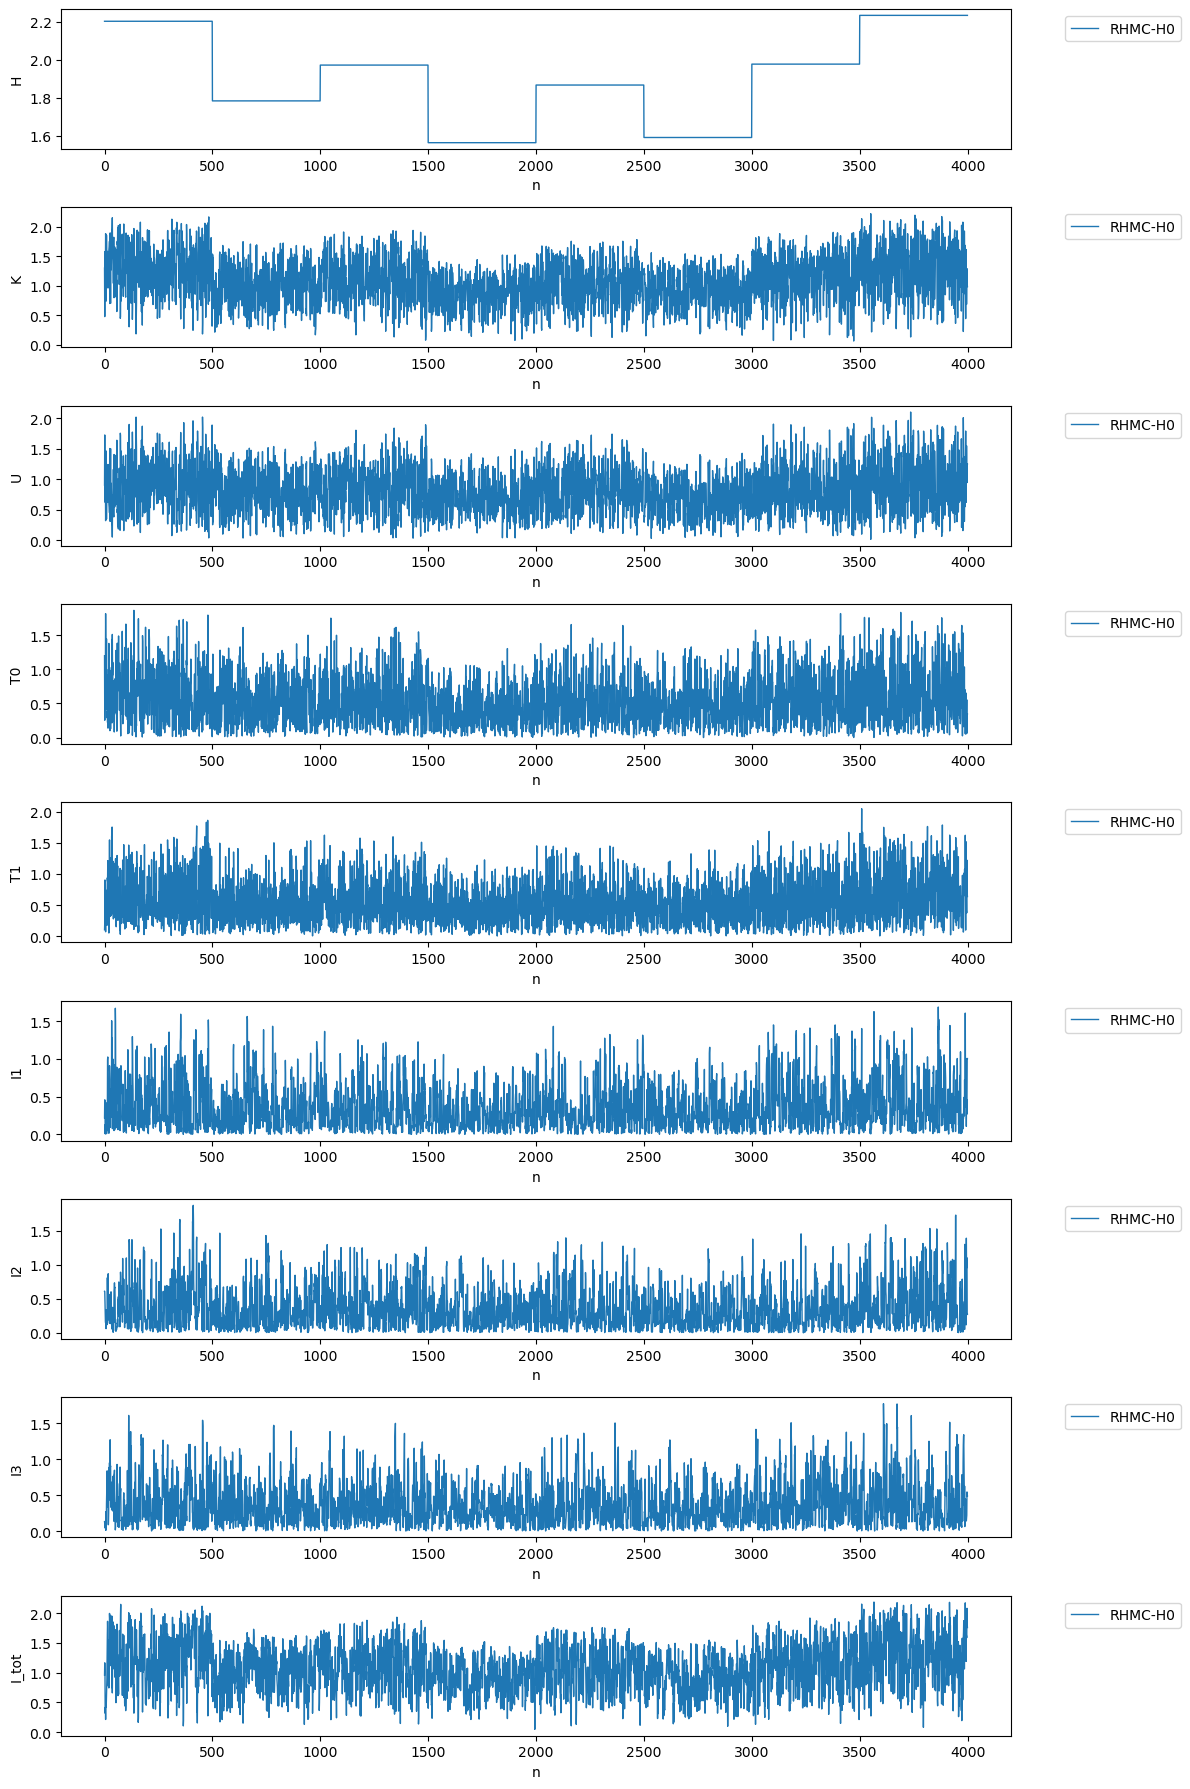

In [9]:
# Trace plot for energies 

energies_of_datasets = [compute_energies(u, omega=50) for u in datasets]

indices = np.arange(len(datasets[0]))[:4000:1]

keys = list(energies_of_datasets[0].keys())
n_subplots = len(keys)

plt.figure(figsize=(12, n_subplots*2))

for i in range(n_subplots):
    plt.subplot(n_subplots, 1, i+1)
    for j in range(len(datasets)):
        plt.plot(indices, energies_of_datasets[j][keys[i]][indices], "-", lw=1, label=label_list[j])
    plt.xlabel("n")
    plt.ylabel(keys[i])
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

plt.tight_layout()
plt.show()

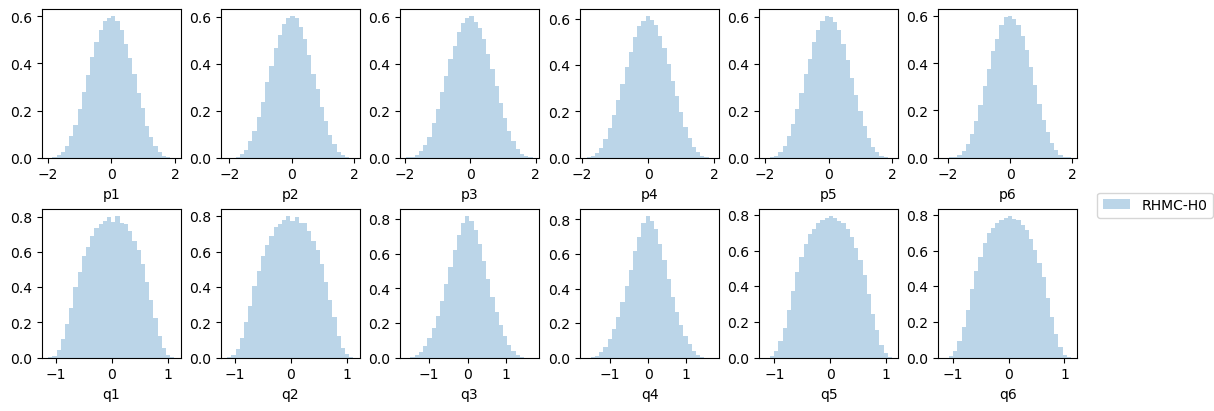

In [10]:
# Marginal probability density plot

indices = np.arange(len(datasets[0]))[::1]
density = True

fig, axes = plt.subplots(2, 6, figsize=(12, 4), layout='constrained')

for i, ax in enumerate(axes.flatten()):
    for u, label in zip(datasets, label_list):
        ax.hist(u[indices, i], bins=30, density=density, alpha=0.3, label=label)
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
    if i < 6:
        ax.set_xlabel(f"p{i+1}")
    else:
        ax.set_xlabel(f"q{i-5}")

fig.legend(handles, labels, loc='outside center right', borderaxespad=0.1)
plt.show()

## Check if data distribution is invariant under the flow

In [12]:
datadir1 = "/workspace/projects_rui/learnsolnmap/data1/fpu/omega=300/version1/Dt=1e0"  # HMC-H0 (old)
datadir2 = "/workspace/projects_rui/learnsolnmap/data1/fpu/omega=300/version4/Dt=1e0"  # RHMC-H0 

Dt = 1e0

datasets1 = [load_data(f"{datadir1}/U{i}.csv")[0] for i in range(6)]
datasets2 = [load_data(f"{datadir2}/U{i}.csv")[0] for i in range(6)]

labels = [f"t={t}" for t in np.arange(6) * Dt]

(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)
(200000, 12)


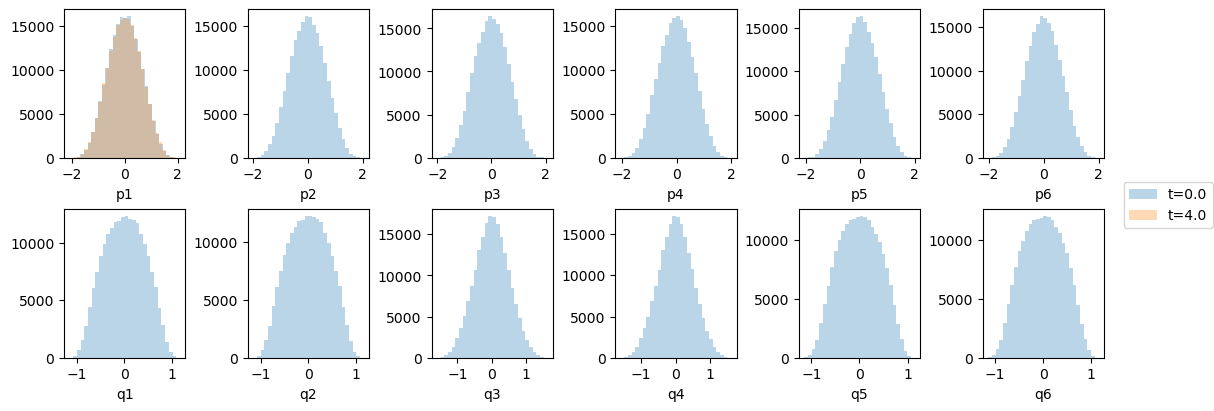

In [21]:
datasets = datasets2

indices = np.arange(len(datasets[0]))[::1]
density = False

fig, axes = plt.subplots(2, 6, figsize=(12, 4), layout='constrained')

for i, ax in enumerate(axes.flatten()):
    for u, label in zip(datasets, labels):
        ax.hist(u[indices, i], bins=30, density=density, alpha=0.3, label=label)
        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
    if i < 6:
        ax.set_xlabel(f"p{i+1}")
    else:
        ax.set_xlabel(f"q{i-5}")

fig.legend(handles, labels, loc='outside center right', borderaxespad=0.1)
plt.show()

In [16]:
from sklearn.metrics import pairwise_kernels

def mmd(X, Y, kernel='rbf'):
    """Compute the Maximum Mean Discrepancy (MMD) between two datasets."""

    # Calculate the kernel matrix
    XX = pairwise_kernels(X, X, metric=kernel)
    YY = pairwise_kernels(Y, Y, metric=kernel)
    XY = pairwise_kernels(X, Y, metric=kernel)

    # Compute MMD statistic
    return XX.mean() + YY.mean() - 2 * XY.mean()

In [17]:
distance_func = mmd 

indices = np.arange(len(datasets1[0]))[::50]

distances1 = []
distances2 = []

for u in datasets1:
    distances1.append(distance_func(datasets1[0][indices], u[indices]))

for u in datasets2:
    distances2.append(distance_func(datasets2[0][indices], u[indices]))

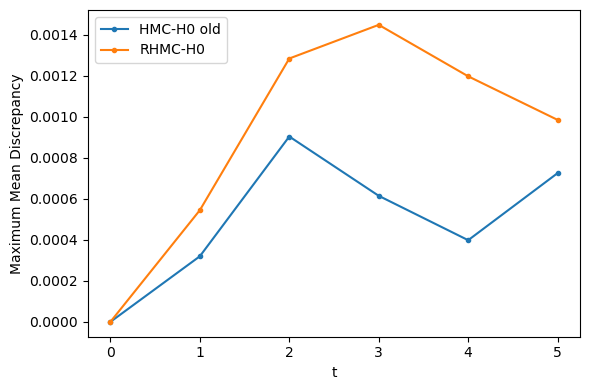

In [19]:
plt.figure(figsize=(6, 4))

plt.subplot(1, 1, 1)
plt.plot(np.arange(len(distances1)) * Dt, distances1, ".-", label="HMC-H0 old")
plt.plot(np.arange(len(distances2)) * Dt, distances2, ".-", label="RHMC-H0")

plt.xlabel("t")
plt.ylabel("Maximum Mean Discrepancy")
plt.legend()

plt.tight_layout()
plt.show()